# Decision Trees

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("input_data/titanic_train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.Survived.value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [5]:
df.shape

(891, 12)

## Data Cleaning

In [6]:
# Finding distinct and total count of columns in the dataset
for col in df.columns:
    cnt=df.groupby(col)['Survived'].count()
    print(cnt)
    #print('count of '+col+' = '+str(cnt))

PassengerId
1      1
2      1
3      1
4      1
5      1
      ..
887    1
888    1
889    1
890    1
891    1
Name: Survived, Length: 891, dtype: int64
Survived
0    549
1    342
Name: Survived, dtype: int64
Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64
Name
Abbing, Mr. Anthony                      1
Abbott, Mr. Rossmore Edward              1
Abbott, Mrs. Stanton (Rosa Hunt)         1
Abelson, Mr. Samuel                      1
Abelson, Mrs. Samuel (Hannah Wizosky)    1
                                        ..
de Mulder, Mr. Theodore                  1
de Pelsmaeker, Mr. Alfons                1
del Carlo, Mr. Sebastiano                1
van Billiard, Mr. Austin Blyler          1
van Melkebeke, Mr. Philemon              1
Name: Survived, Length: 891, dtype: int64
Sex
female    314
male      577
Name: Survived, dtype: int64
Age
0.42     1
0.67     1
0.75     2
0.83     2
0.92     1
        ..
70.00    2
70.50    1
71.00    2
74.00    1
80.00    1
Name: Survived, Length

Passenger ID and Name are unique identifiers for each passenger.

Name is unique to each individual and does not provide predictive power.

Fare varies across passengers and can be an informative feature.

Cabin numbers differ for each passenger, but it may be useful to extract the alphabet and numeric components separately.

The alphabet could represent the coach/deck, which might have an influence on survival.

In [7]:
#Dropping passenger_id and name from df
df.drop('PassengerId',axis=1,inplace=True)
df.drop('Name',axis=1,inplace=True)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
#Extracting cabin alphabets 
df['Cabin_alphabet']=df['Cabin'].str[0]
df.drop('Cabin',axis=1,inplace=True)

In [10]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_alphabet
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S,NaN
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,NaN
3,1,1,female,35.0,1,0,113803,53.1000,S,C
4,0,3,male,35.0,0,0,373450,8.0500,S,NaN


In [11]:
print("Total number of rows: ",df.shape[0])
for i in df.columns:
    print(i,":",df[i].isna().sum())

Total number of rows:  891
Survived : 0
Pclass : 0
Sex : 0
Age : 177
SibSp : 0
Parch : 0
Ticket : 0
Fare : 0
Embarked : 2
Cabin_alphabet : 687


1. Here, the rows with Embarked null can be dropped ( As number is very low compared to dataset)
1. Age needs to be intrapolated with the median age ( Numberical Variable)
1. For cabin, a new category as not specified should be intoduced ( Categorical Variable)

In [12]:
df = df.dropna(subset=['Embarked'])
df['Age']=df['Age'].fillna(df['Age'].median())
df['Cabin_alphabet']=df['Cabin_alphabet'].fillna('Cabin_missing')

In [13]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_alphabet
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Cabin_missing
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Cabin_missing
3,1,1,female,35.0,1,0,113803,53.1000,S,C
4,0,3,male,35.0,0,0,373450,8.0500,S,Cabin_missing


## Data preperation

Finding the correlation between the variables and creating a correlation graph

In [14]:
df_numerical = df[['Age','Fare','Survived']]
numerical_variables=df_numerical.columns

df_categorical = df[[col for col in df.columns if col not in ['Age', 'Fare']]]
categorical_variables=df_categorical.columns

In [15]:
def corr_graph(df_numerical):
    corr=df_numerical.corr().round(2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title("Correlation Heatmap")
    plt.show()

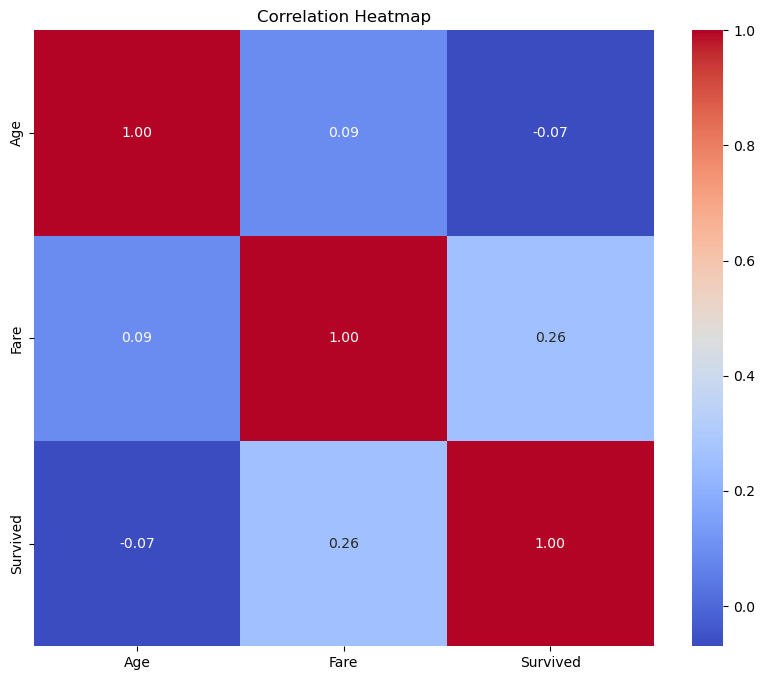

In [16]:
corr_graph(df_numerical)

There are no two variables with High correlation. So, moving ahead!

In [17]:
df_numerical.groupby('Survived').agg(['mean'])

,Age,Fare
,mean,mean
Survived,,
0,30.028233,22.117887
1,28.163735,48.209498


For numerical variable, plotting box plot

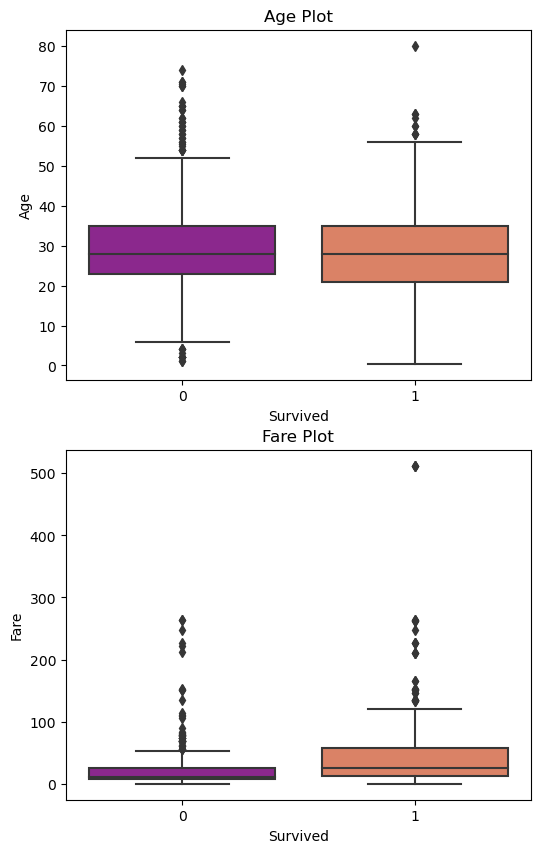

In [18]:
cols=df_numerical.columns
cols=[c for c in cols if c!='Survived']
l=len(cols)
plt.figure(figsize=(6,10))
for i in range(l):
    plt.subplot(l,1,i+1)
    sns.boxplot(x=df.Survived,y=df[cols[i]],palette=("plasma"))
    plt.title(cols[i]+' Plot')
plt.show()

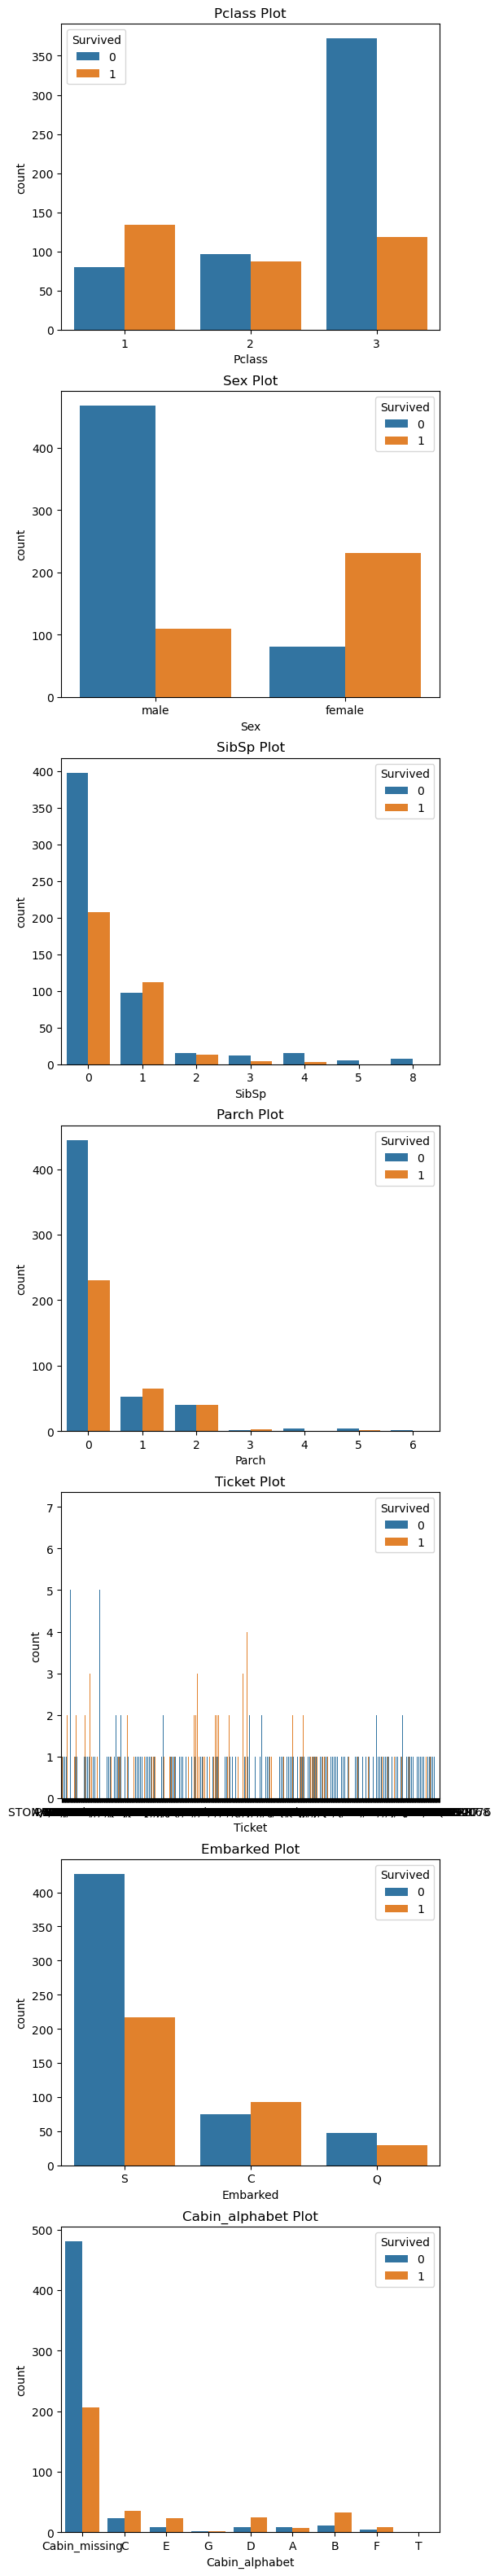

In [19]:
cols=df_categorical.columns
cols=[c for c in cols if c!='Survived']
l=len(cols)
plt.figure(figsize=(6,40))
for i in range(l):
    plt.subplot(l,1,i+1)
    sns.countplot(x=df[cols[i]], hue="Survived", data=df)
    #sns.histplot(x=df.Survived,y=df[cols[i]],palette=("plasma"))
    plt.title(cols[i]+' Plot')
plt.show()

## Data Scaling and Dummy Variables 

Scaling numerical Columns

In [20]:
numerical_variables= [c for c in numerical_variables if c!='Survived']
categorical_variables= [c for c in categorical_variables if c!='Survived']

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[numerical_variables]=scaler.fit_transform(df[numerical_variables])

Dummy Variables for categorical Columns

In [22]:
l=len(categorical_variables)

for i in range(l):
    temp=pd.get_dummies(df[categorical_variables[i]],drop_first=True,prefix=categorical_variables[i],prefix_sep='_')
    df=pd.concat([df,temp],axis=1)
    df.drop(categorical_variables[i],axis=1,inplace=True)

In [23]:
df.head()

,Survived,Age,Fare,Pclass_2,Pclass_3,Sex_male,SibSp_1,SibSp_2,SibSp_3,SibSp_4,...,Embarked_Q,Embarked_S,Cabin_alphabet_B,Cabin_alphabet_C,Cabin_alphabet_Cabin_missing,Cabin_alphabet_D,Cabin_alphabet_E,Cabin_alphabet_F,Cabin_alphabet_G,Cabin_alphabet_T
0,0,0.271174,0.014151,0,1,1,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
1,1,0.472229,0.139136,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1,0.321438,0.015469,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
3,1,0.434531,0.103644,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
4,0,0.434531,0.015713,0,1,1,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0


## Train test Split

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
np.random.seed(20)

In [26]:
df_train,df_test=train_test_split(df,train_size=0.7,test_size=0.3,random_state=100)

In [27]:
y_train=df_train.pop('Survived')
x_train=df_train

In [28]:
y_test=df_test.pop('Survived')
x_test=df_test

## Model Building

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Model 1: No pruning

In [30]:
# Defining the variables
x_train_np=x_train
y_train_np=y_train
x_test_np=x_test
y_test_np=y_test

In [31]:
clf_np=DecisionTreeClassifier(random_state=0)
a_np=clf_np.fit(x_train_np,y_train_np)

In [32]:
print(clf_np)

DecisionTreeClassifier(random_state=0)


In [33]:
y_train_np_pred_proba = clf_np.predict_proba(x_train_np)[:,1]
y_test_np_pred_proba = clf_np.predict_proba(x_test_np)[:,1]
y_train_np_pred = clf_np.predict(x_train_np)
y_test_np_pred = clf_np.predict(x_test_np)

In [34]:
print('No Pruning')
print('Train AUC score '+ str(roc_auc_score(y_train_np,y_train_np_pred_proba)))
print("Test AUC score "+str(roc_auc_score(y_test_np,y_test_np_pred_proba)))
#plot_confusionmatrix(y_train_np_pred,y_train_np,dom='Train')
#plot_confusionmatrix(y_test_np_pred,y_test_np,dom='Test')

No Pruning
Train AUC score 0.9999779339563313
Test AUC score 0.773948598130841


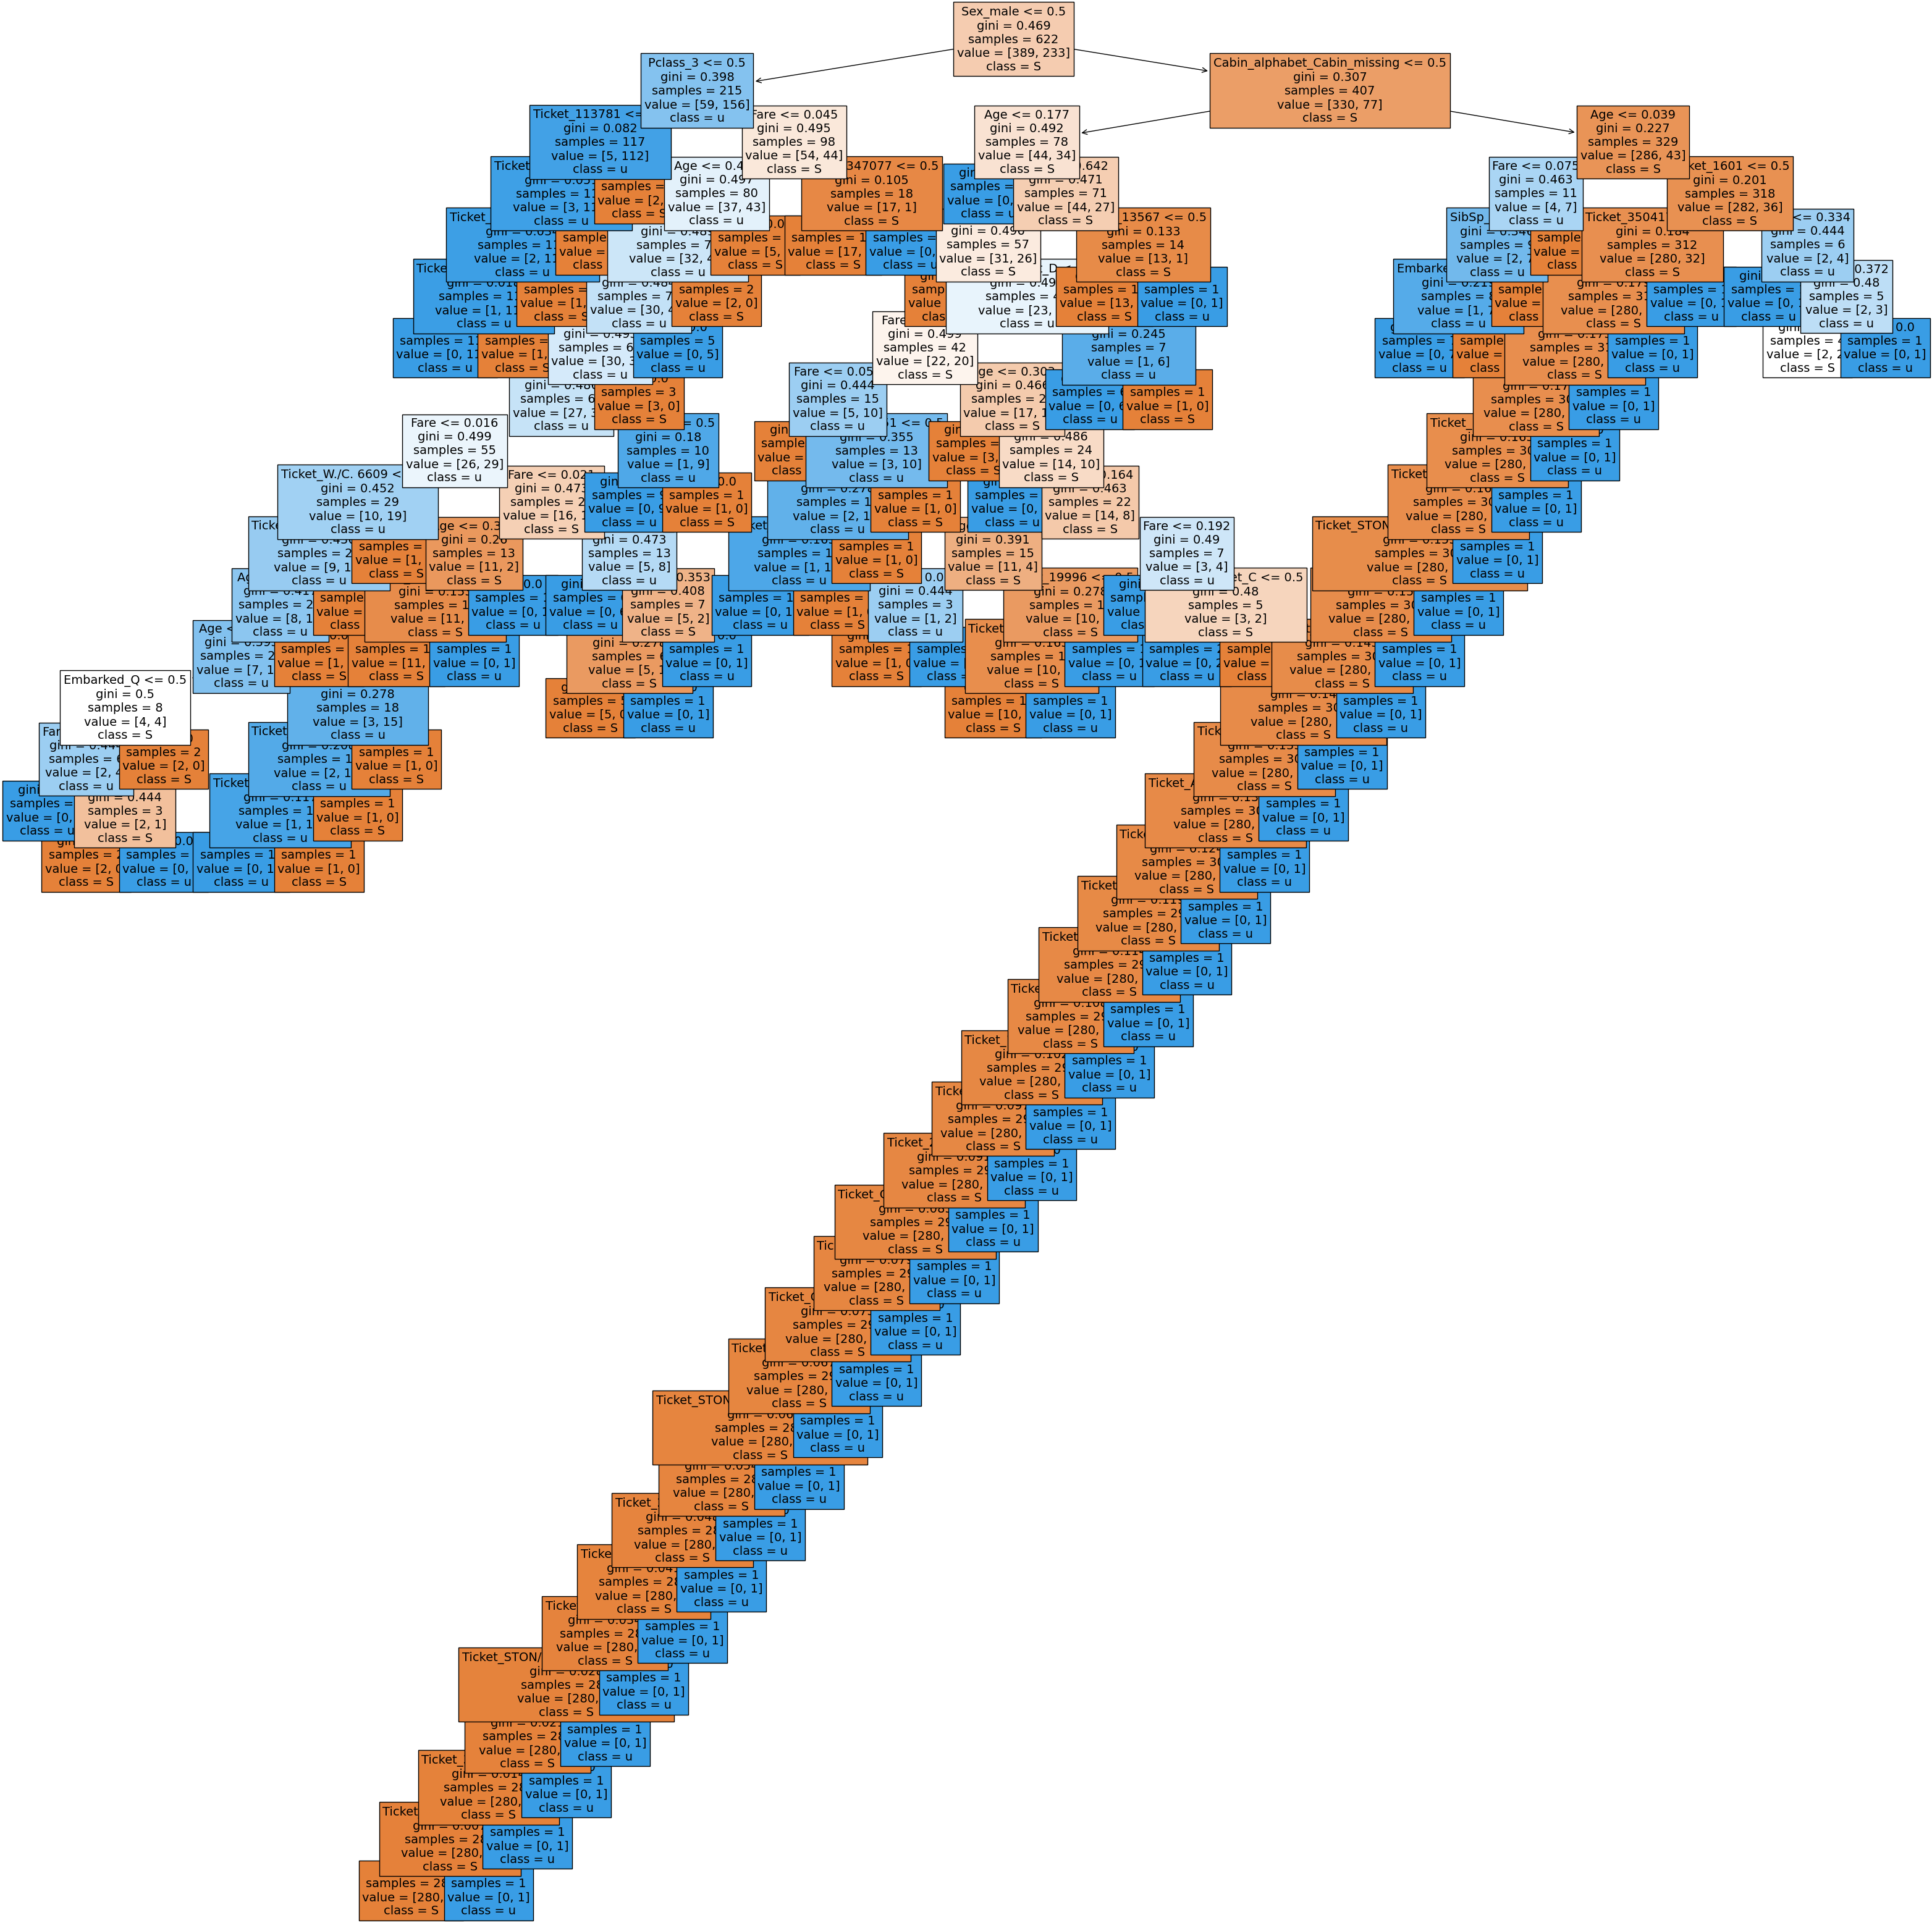

In [35]:
# Plotting the decision tree for no Pruning case
plt.figure(figsize=(40,40))
plot_tree(clf_np, filled=True, feature_names=x_train_np.columns, class_names=y_train_np.name,fontsize=14)
plt.show()

### Model 2: Pre- pruning

In [36]:
x_train_pre=x_train
y_train_pre=y_train
x_test_pre=x_test
y_test_pre=y_test

In [37]:
params = {'max_depth': [2,4,6,8,10,12,14,16,18,20,22,21],
         'min_samples_split': [10,15,20,25,30,1],
         'min_samples_leaf': [5,10,15,20,1]}

clf_pre = DecisionTreeClassifier()
gcv = GridSearchCV(estimator=clf_pre,param_grid=params,cv=5,scoring='roc_auc')
gcv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22,
                                       21],
                         'min_samples_leaf': [5, 10, 15, 20, 1],
                         'min_samples_split': [10, 15, 20, 25, 30, 1]},
             scoring='roc_auc')

In [38]:
model_pre = gcv.best_estimator_
model_pre.fit(x_train_pre,y_train_pre)
y_train_pre_pred = model_pre.predict(x_train_pre)
y_test_pre_pred = model_pre.predict(x_test_pre)
y_train_pre_pred_proba = model_pre.predict_proba(x_train_pre)[:,1]
y_test_pre_pred_proba = model_pre.predict_proba(x_test_pre)[:,1]
print(model_pre)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15, min_samples_split=20)


In [39]:
print('Pre-Pruning')
print(f'Train AUC score {roc_auc_score(y_train_pre,y_train_pre_pred_proba)}')
print(f'Test AUC score {roc_auc_score(y_test_pre,y_test_pre_pred_proba)}')

Pre-Pruning
Train AUC score 0.9062579299844435
Test AUC score 0.8298773364485983


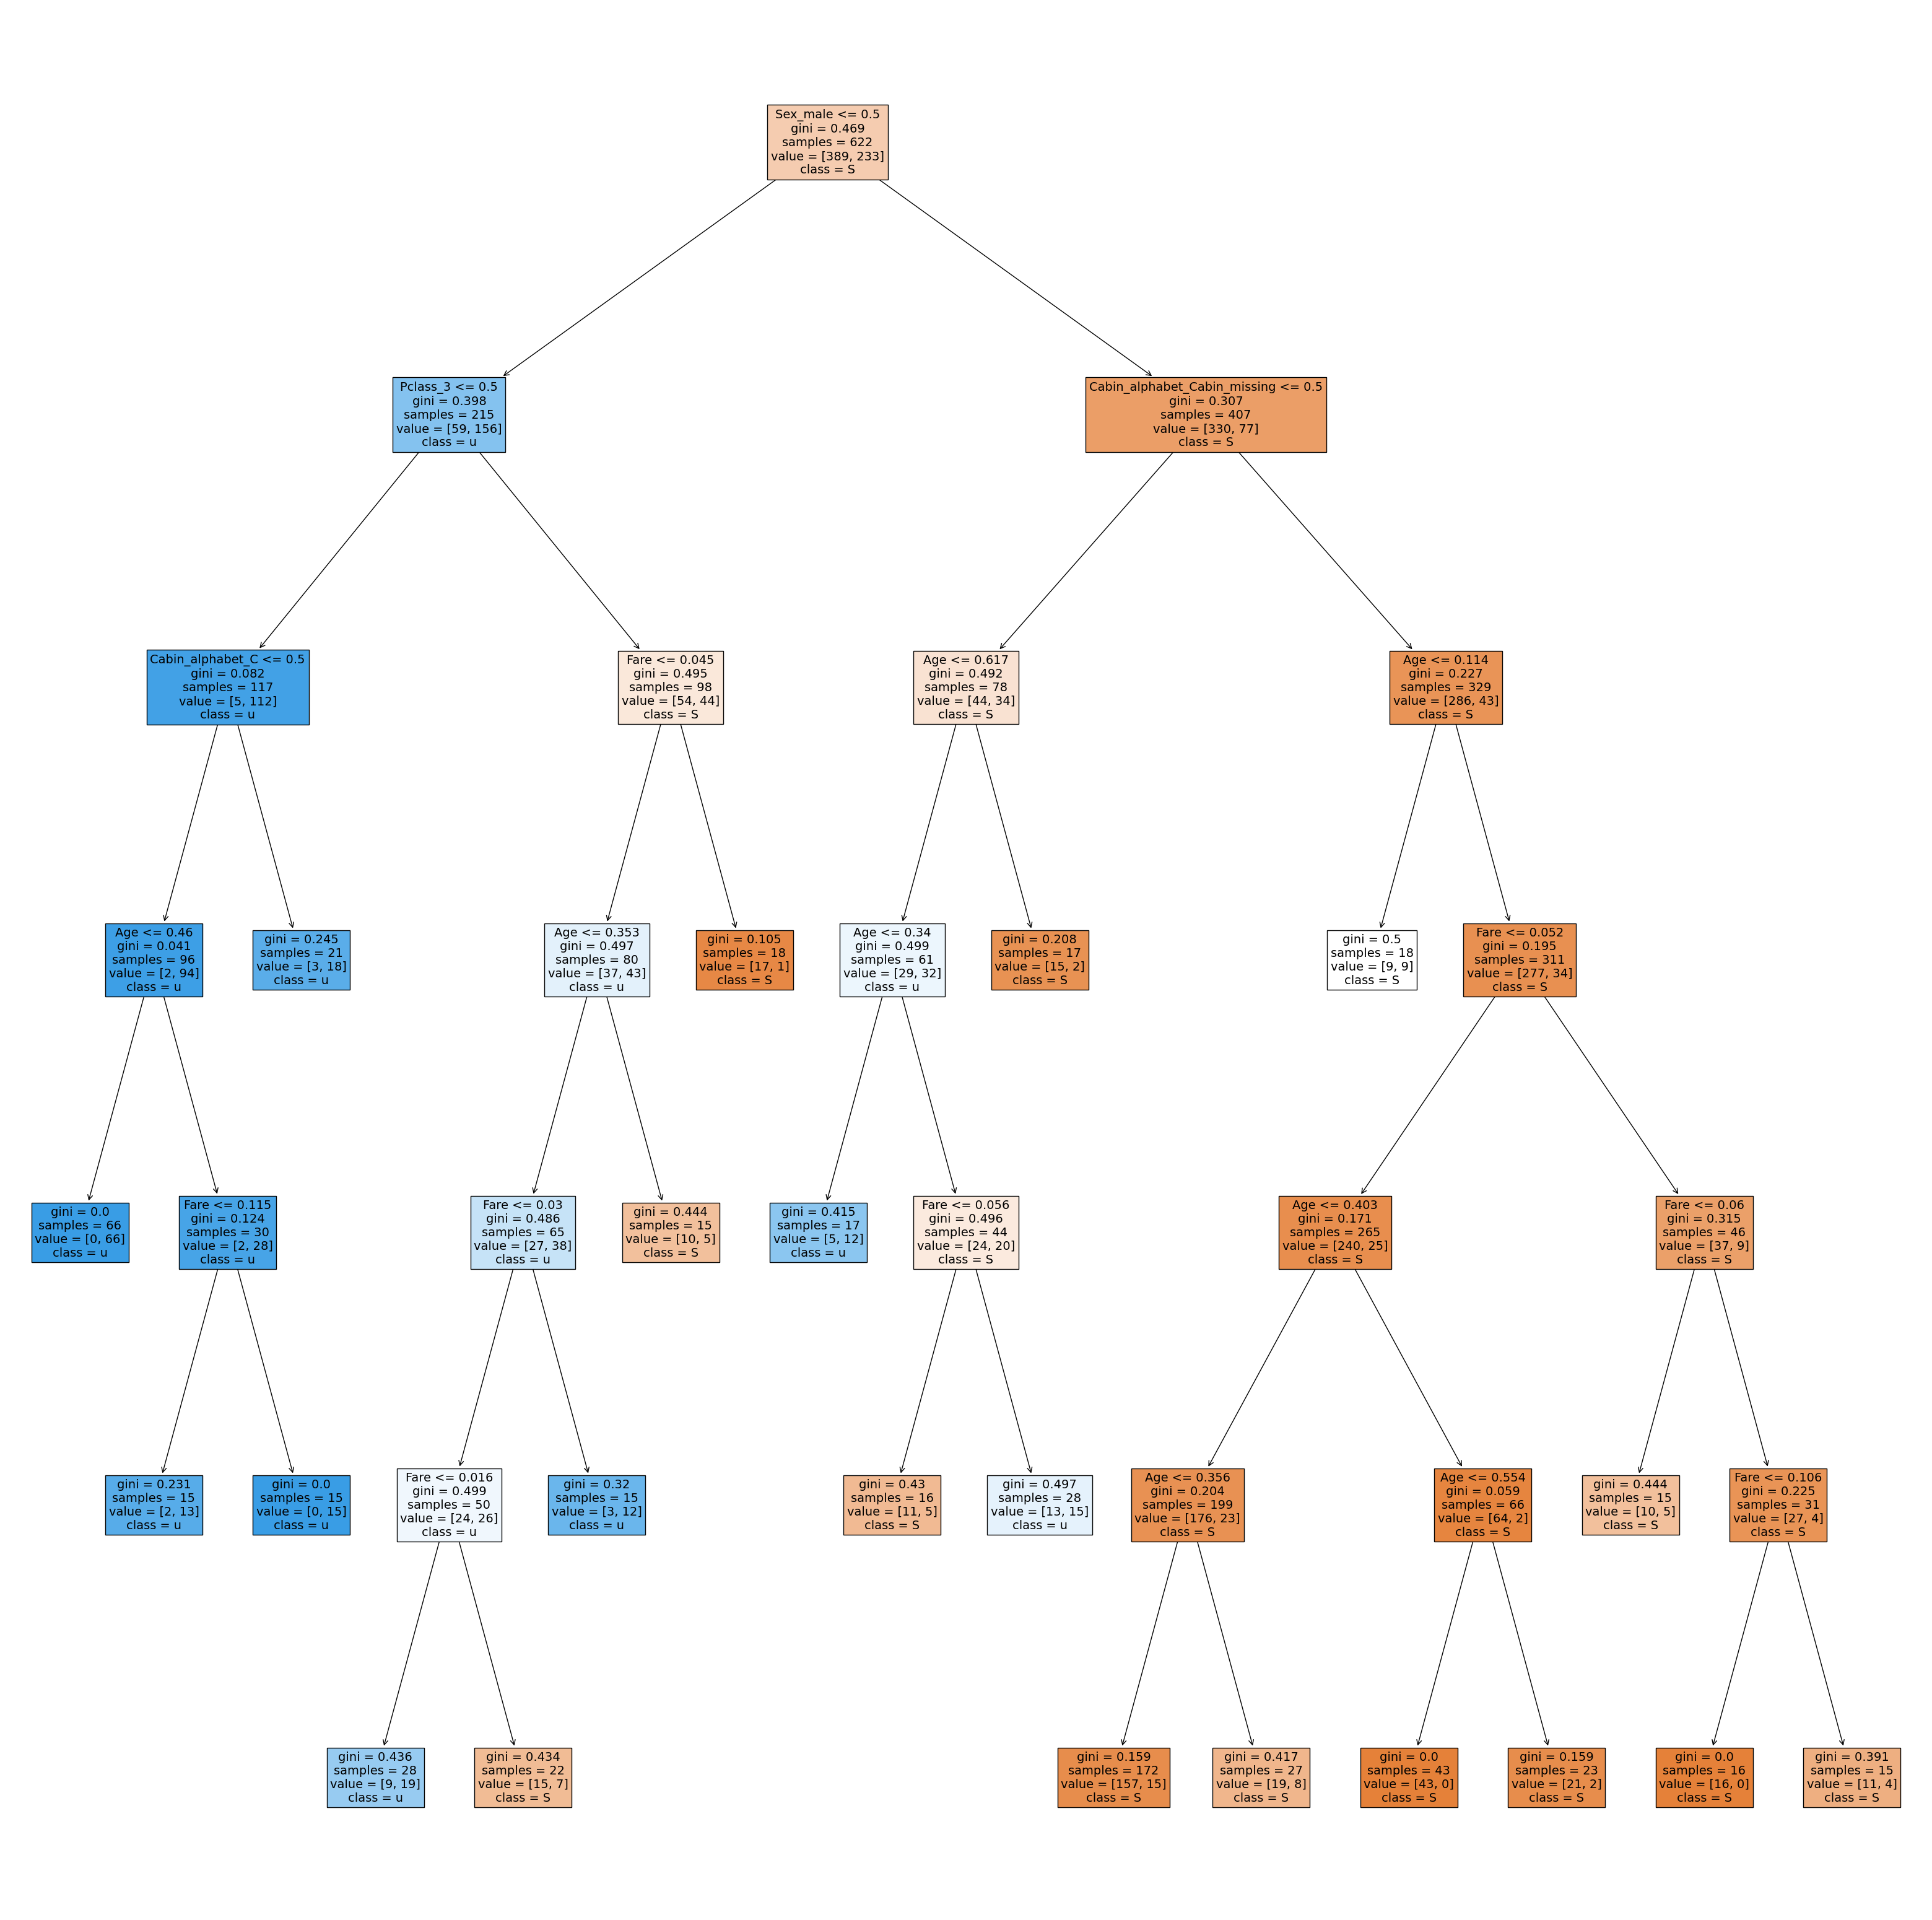

In [40]:
# Plotting the decision tree for Pre-Pruning case
plt.figure(figsize=(40,40))
plot_tree(model_pre, filled=True, feature_names=x_train_pre.columns, class_names=y_train_pre.name,fontsize=14)
plt.show()

### Model 3: Post Pruning

In [41]:
# splitting the data into test,train and validation sets
df_trainval,df_test_post = train_test_split(df, test_size=0.3, random_state=100)
df_train_post,df_val_post = train_test_split(df_trainval, test_size=0.1, random_state=100)

In [42]:
y_train_post=df_train_post.pop('Survived')
x_train_post=df_train_post
y_test_post=df_test_post.pop('Survived')
x_test_post=df_test_post
y_val_post=df_val_post.pop('Survived')
x_val_post=df_val_post

In [43]:
clf_post=DecisionTreeClassifier()
clf_post.fit(x_train_post,y_train_post)

DecisionTreeClassifier()

In [44]:
path = clf_post.cost_complexity_pruning_path(x_train_post, y_train_post)

In [45]:
print(pd.DataFrame(path).sort_values(by='impurities' ,ascending =False).head())

    ccp_alphas  impurities
30    0.132562    0.465423
29    0.046938    0.332862
28    0.019634    0.285924
27    0.010830    0.266290
26    0.009825    0.255460


In [46]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)
print(pd.DataFrame(clfs).head())

                                                   0
0             DecisionTreeClassifier(random_state=0)
1  DecisionTreeClassifier(ccp_alpha=0.00095408467...
2  DecisionTreeClassifier(ccp_alpha=0.00214669051...
3  DecisionTreeClassifier(ccp_alpha=0.00238521168...
4  DecisionTreeClassifier(ccp_alpha=0.00238521168...


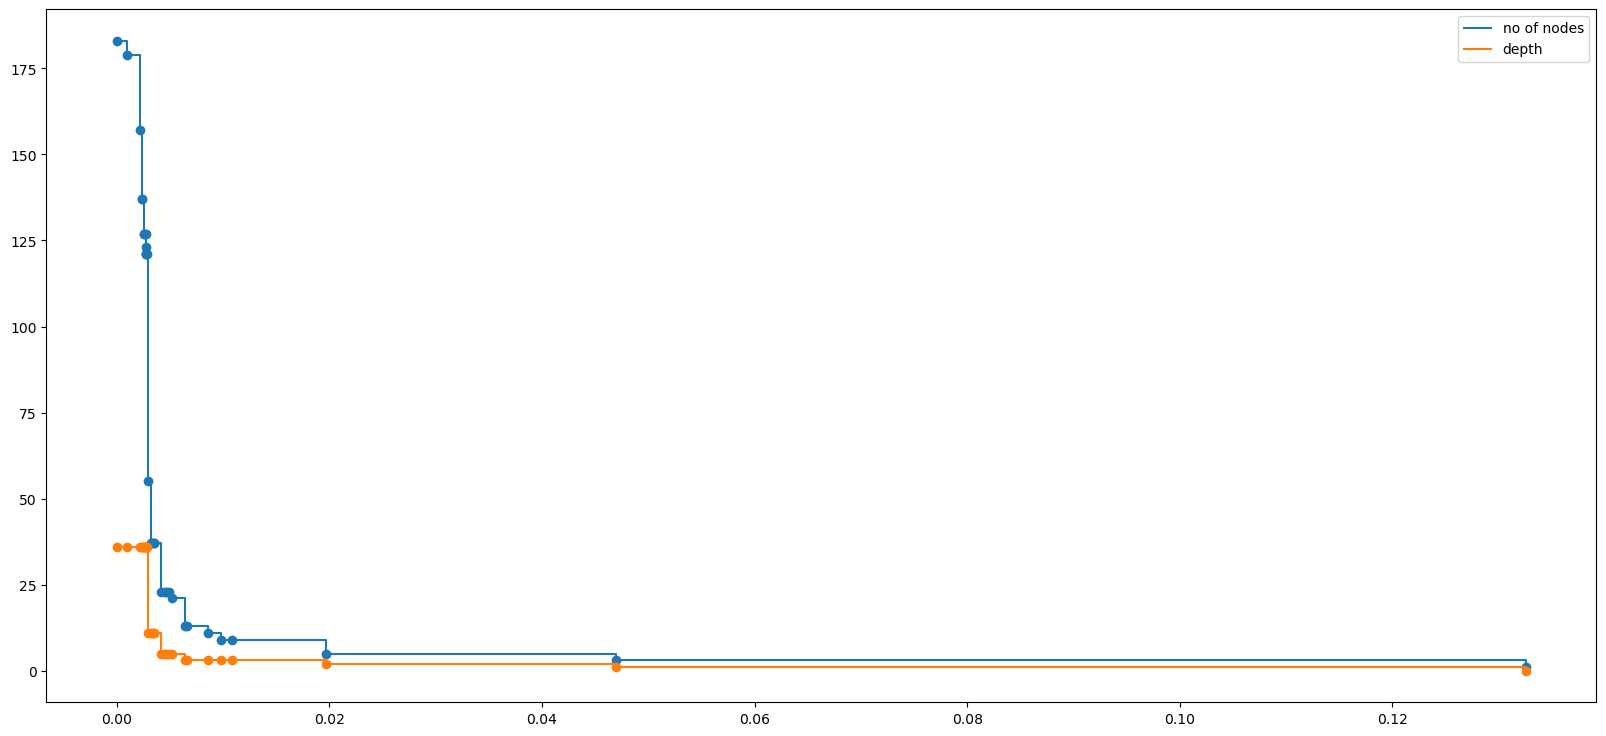

In [47]:
# to check if the decision tree becomes less complex with increasing alpha
node_count=[ clf.tree_.node_count for clf in clfs]
depth=[ clf.tree_.max_depth for clf in clfs]

plt.figure(figsize=(20,9))
plt.scatter(ccp_alphas,node_count)
plt.scatter(ccp_alphas,depth)
plt.plot(ccp_alphas,node_count,label='no of nodes',drawstyle="steps-post")
plt.plot(ccp_alphas,depth,label='depth',drawstyle="steps-post")
plt.legend()
plt.show()

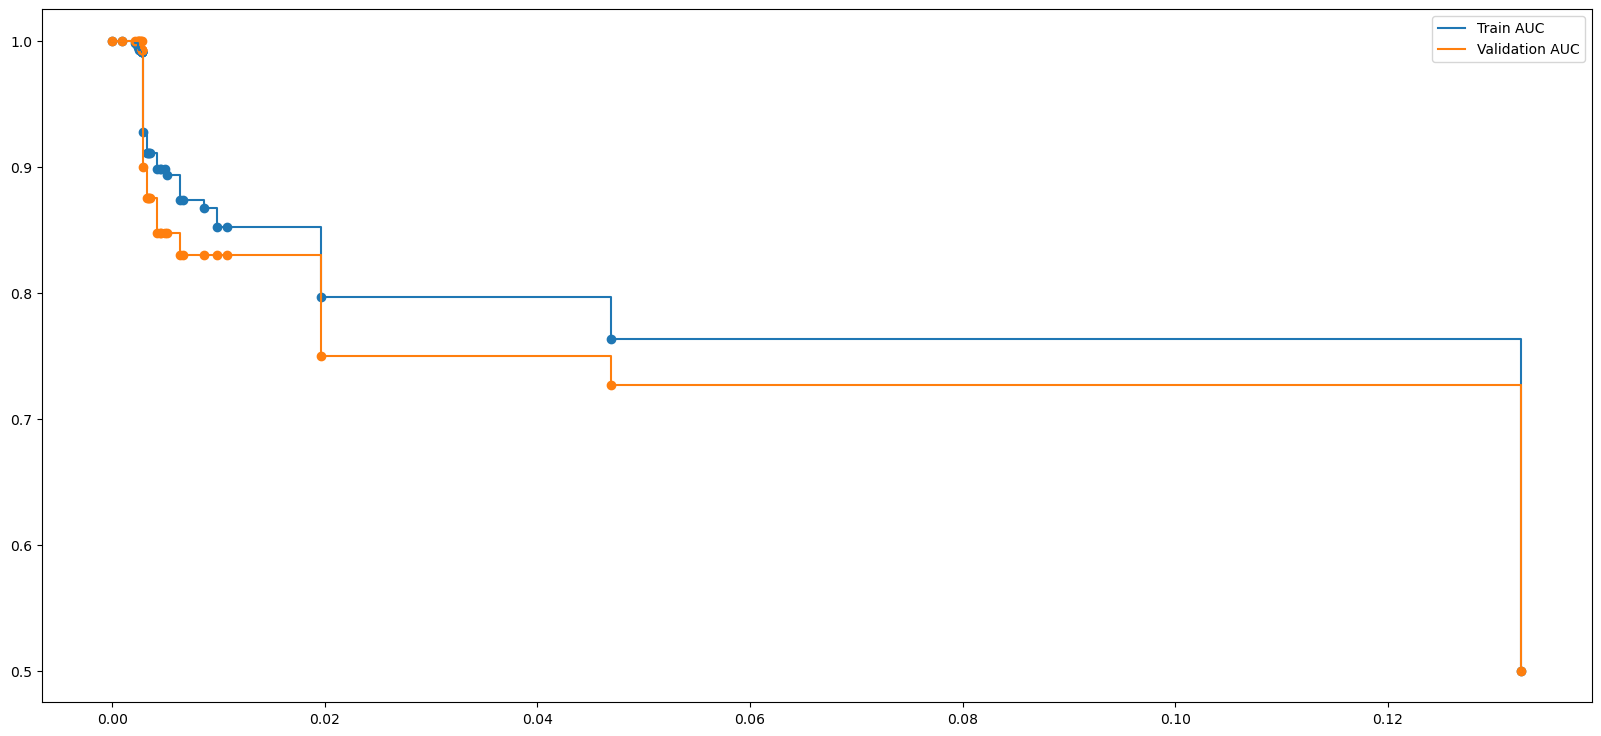

In [48]:
#to check the accuracy of different alpha on the validation set and deciding on the alpha to use

train_post_acc = []
val_post_acc = []

for c in clfs:
    y_train_prob = c.predict_proba(x_train_post)[:, 1]
    y_val_prob   = c.predict_proba(x_val_post)[:, 1]
    train_post_acc.append(roc_auc_score(y_train_post,y_train_prob))
    val_post_acc.append(roc_auc_score(y_val_post,y_val_prob))
    
plt.figure(figsize=(20,9))
plt.scatter(ccp_alphas,train_post_acc)
plt.scatter(ccp_alphas,val_post_acc)
plt.plot(ccp_alphas,train_post_acc,label='Train AUC',drawstyle="steps-post")
plt.plot(ccp_alphas,val_post_acc,label='Validation AUC',drawstyle="steps-post")
plt.legend()
plt.show()

In [49]:
ba = pd.DataFrame({
    'ccp_alphas': ccp_alphas,
    'val_post_acc': val_post_acc
})
best_alpha=ba.loc[ba['val_post_acc']==ba['val_post_acc'].max()] 
a=best_alpha['ccp_alphas'].max() ## So that we choose the most simplified tree without compromising on AUC
print(a)

0.002146690518783542


From here, the alpha=a will be fit 

In [50]:
clf_post = DecisionTreeClassifier(random_state=0,ccp_alpha=a)
clf_post.fit(x_train_post,y_train_post)
y_train_post_pred = clf_post.predict(x_train_post)
y_test_post_pred = clf_post.predict(x_test_post)
y_train_post_pred_proba = clf_post.predict_proba(x_train_post)[:,1]
y_test_post_pred_proba = clf_post.predict_proba(x_test_post)[:,1]

print('Post Pruning')
print(f'Train score {roc_auc_score(y_train_post,y_train_post_pred_proba)}')
print(f'Test score {roc_auc_score(y_test_post,y_test_post_pred_proba)}')

Post Pruning
Train score 0.9998349789598174
Test score 0.7820385514018691


### Model 4: Post - Pruning with cross-validation

In [51]:
x_train_postcv=x_train
y_train_postcv=y_train
x_test_postcv=x_test
y_test_postcv=y_test

In [52]:
clf_postcv=DecisionTreeClassifier()
clf_postcv.fit(x_train_postcv,y_train_postcv)

DecisionTreeClassifier()

In [53]:
path = clf_postcv.cost_complexity_pruning_path(x_train_postcv, y_train_postcv)
ccp_alphas,impurites=path.ccp_alphas,path.impurities

In [54]:
param_grid = {'ccp_alpha': ccp_alphas}

In [55]:
grid_search = GridSearchCV(
    estimator=clf_postcv,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='roc_auc' 
)

grid_search.fit(x_train_postcv, y_train_postcv)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': array([0.        , 0.00053591, 0.00191515, 0.00214362, 0.00226271,
       0.00229674, 0.00247341, 0.00250089, 0.00272075, 0.00275609,
       0.00288565, 0.00289389, 0.00293993, 0.00298576, 0.0030368 ,
       0.00313155, 0.00318295, 0.003571  , 0.00495445, 0.00578737,
       0.00599545, 0.0060233 , 0.00786847, 0.00935677, 0.01097413,
       0.01888426, 0.04430251, 0.13015085])},
             scoring='roc_auc')

In [56]:
model_postcv = grid_search.best_estimator_
model_postcv.fit(x_train_postcv,y_train_postcv)
y_train_postcv_pred = model_postcv.predict(x_train_postcv)
y_test_postcv_pred = model_postcv.predict(x_test_postcv)
y_train_postcv_pred_proba = model_postcv.predict_proba(x_train_postcv)[:,1]
y_test_postcv_pred_proba = model_postcv.predict_proba(x_test_postcv)[:,1]
print(model_postcv)

DecisionTreeClassifier(ccp_alpha=0.004954448017148977)


In [57]:
print('Post- Pruning Cross- Validation')
print('Train AUC score:'+ str(roc_auc_score(y_train_postcv,y_train_postcv_pred_proba)))
print('Test AUC score:'+ str(roc_auc_score(y_test_postcv,y_test_postcv_pred_proba)))

Post- Pruning Cross- Validation
Train AUC score:0.8860895660712513
Test AUC score:0.8014310747663551


## All the AUC scores at one place

In [58]:
print('No Pruning')
print('Train AUC score '+ str(roc_auc_score(y_train_np,y_train_np_pred_proba)))
print("Test AUC score "+str(roc_auc_score(y_test_np,y_test_np_pred_proba)))

print('Pre-Pruning')
print(f'Train AUC score {roc_auc_score(y_train_pre,y_train_pre_pred_proba)}')
print(f'Test AUC score {roc_auc_score(y_test_pre,y_test_pre_pred_proba)}')

print('Post Pruning')
print(f'Train score {roc_auc_score(y_train_post,y_train_post_pred_proba)}')
print(f'Test score {roc_auc_score(y_test_post,y_test_post_pred_proba)}')

print('Post- Pruning Cross- Validation')
print('Train AUC score:'+ str(roc_auc_score(y_train_postcv,y_train_postcv_pred_proba)))
print('Test AUC score:'+ str(roc_auc_score(y_test_postcv,y_test_postcv_pred_proba)))

No Pruning
Train AUC score 0.9999779339563313
Test AUC score 0.773948598130841
Pre-Pruning
Train AUC score 0.9062579299844435
Test AUC score 0.8298773364485983
Post Pruning
Train score 0.9998349789598174
Test score 0.7820385514018691
Post- Pruning Cross- Validation
Train AUC score:0.8860895660712513
Test AUC score:0.8014310747663551


1. In the case of No Pruning, the model shows clear signs of overfitting.
1. Same is the case with Post-Pruning using a Validation Set

1. For both Pre-Pruning and Post-Pruning with Cross-Validation, the training and test AUC scores are very close, indicating that the models generalize well without overfitting.

1. Therefore, we proceed with Model 4 (Post-Pruning with Cross-Validation) as the final choice, since it exhibits no overfitting and achieves the highest AUC on the test data.

In [59]:
y_pred_proba=y_test_postcv_pred_proba
y_pred=y_test_postcv_pred
y_test=y_test_postcv

## Evaluation

In [60]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

In [61]:
Confusion_matrix=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", Confusion_matrix)

Confusion Matrix:
 [[129  31]
 [ 26  81]]


In [62]:
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

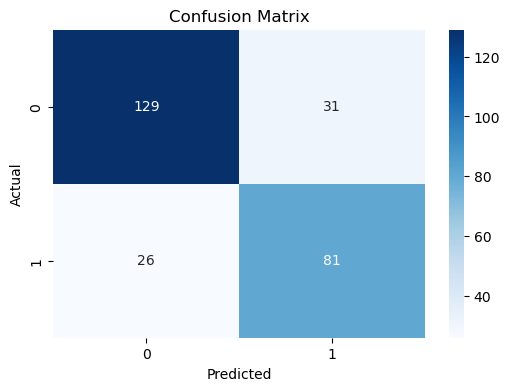

In [63]:
plot_confusion_matrix(Confusion_matrix, model_postcv)

In [64]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :",roc_auc_score(y_test, y_pred_proba))

Accuracy : 0.7865168539325843
Precision: 0.7232142857142857
Recall   : 0.7570093457943925
F1 Score : 0.7397260273972601
ROC-AUC  : 0.8014310747663551


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       160
           1       0.72      0.76      0.74       107

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267



### Summary
1. A Decision Tree was trained on passenger data to predict survival, achieving an accuracy of 79%.
1. The model was evaluated under different pruning strategies:
   1. No pruning
   2. Pre-pruning with Cross-validation
   3. Post-Pruning with validation set
   4. Post-Pruning with Cross-validation
1. Post-Pruning with Cross-validation was chosen as final model on the basis of its performance on the test data
1. Finally, the model was assessed with Confusion Matrix and Classification report